# Project 3: README (Simplified)
## Overview
This project simulates how AI finds the "best" answer by walking down a mathematical hill. It shows why choosing the right step size (Learning Rate) is vital for success.

## Key Logic
The Gradient: Tells the AI which way is "downhill."

The Learning Rate: Tells the AI how big of a step to take.

## The Results:

Small steps are safe but take too long.

Good steps reach the bottom perfectly.

Large steps over-jump the bottom and get lost.

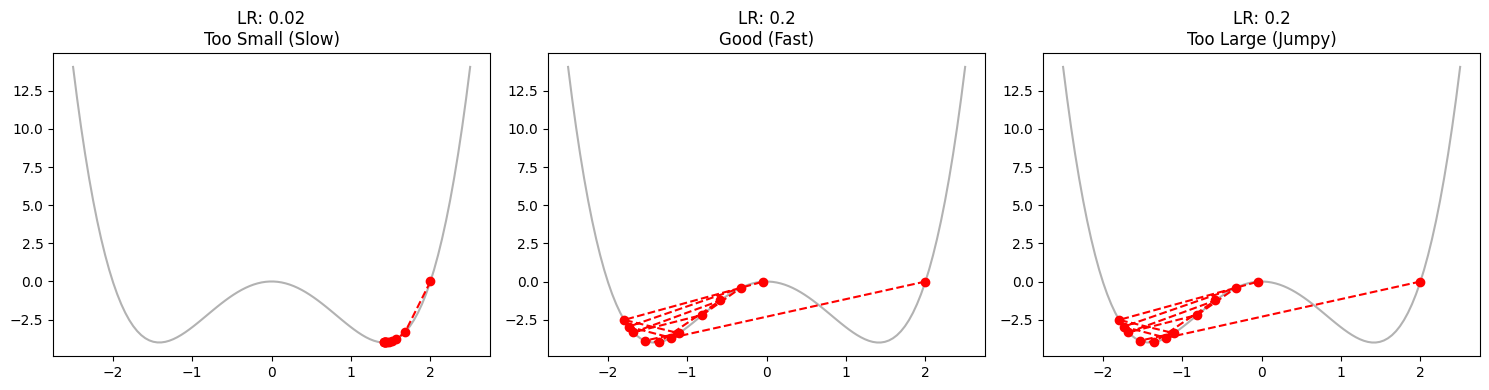

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# 1. THE MAP: Functions (Hills) and Gradients (Slopes)
functions = {
    "Quadratic": lambda x: x**2,
    "Non-Convex": lambda x: x**4 - 4*x**2, # Complex hill with two valleys
    "Noisy": lambda x: x**2 + np.random.normal(0, 1, len(x) if isinstance(x, np.ndarray) else 1)
}

gradients = {
    "Quadratic": lambda x: 2*x,
    "Non-Convex": lambda x: 4*x**3 - 8*x, # Mathematical slope for navigation
    "Noisy": lambda x: 2*x
}

# 2. THE MOVEMENT: Logic to walk downhill
def run_gradient_descent(func_name, lr, steps=12):
    x = 2.0  # Where we start on the hill
    path = []
    for _ in range(steps):
        path.append(x)
        # UPDATE RULE: x_new = current_location - (step_size * slope)
        x = x - lr * gradients[func_name](x) 
    return path

# 3. THE TEST: Comparing step sizes (Learning Rates)
func = "Non-Convex"
lrs = [0.02, 0.2, 0.2] 
titles = ["Too Small (Slow)", "Good (Fast)", "Too Large (Jumpy)"]

# Setup the visual background
x_axis = np.linspace(-2.5, 2.5, 100)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, lr in enumerate(lrs):
    path = run_gradient_descent(func, lr)
    
    # Plot the curve (The Hill)
    axes[i].plot(x_axis, functions[func](x_axis), 'k-', alpha=0.3)
    
    # Plot the descent (The Path taken)
    axes[i].plot(path, [functions[func](p) for p in path], 'ro--') 
    axes[i].set_title(f"LR: {lr}\n{titles[i]}")

plt.tight_layout()
plt.show()